# Redispatch volume matched to power plants

How much of the German redispatch **volume (MWh)** we resolve to identifiable power plants,
via the matching pipeline (see `docs/matching-pipeline.md`). Volume-weighted, not entry counts.

Source: `data/Redispatch_Daten_2021.csv` (2021–2026, the fuller extract). The matcher was
run over this full name set, so every event's `BETROFFENE_ANLAGE` is in scope; each is
joined to `results/redispatch_plant_matches.csv`.

**Categories**
- **matched · high / medium / low** — resolved to a plant (or plant-set), by match confidence
- **aggregate (no plant)** — structurally unmatchable by design: countertrade (`Börse`),
  control-reserve nodes, substations, regional renewable buckets, emergency, foreign plants
- **unmatched (in scope)** — a name we processed but couldn't resolve
- **unmatched (out of scope)** — a name not in the lookup (≈0 now that the matcher covers the
  full 2021–2026 name set, including plants retired during these years)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

REDISPATCH = "data/Redispatch_Daten_2021.csv"      # 2021-2026, carries GESAMTE_ARBEIT_MWH
MATCHES    = "results/redispatch_plant_matches.csv"

r = pd.read_csv(REDISPATCH, sep=";", encoding="utf-8-sig", low_memory=False)
r.columns = r.columns.str.strip()
r["year"] = pd.to_datetime(r["BEGINN_DATUM"], format="%d.%m.%Y", errors="coerce").dt.year
r["mwh"]  = pd.to_numeric(r["GESAMTE_ARBEIT_MWH"].astype(str).str.replace(",", ".", regex=False),
                          errors="coerce").abs()
r = r.dropna(subset=["year", "mwh"]).astype({"year": int})

m = pd.read_csv(MATCHES)
STRUCT = {"control_reserve", "substation", "regional_renewable", "countertrade", "emergency", "foreign"}
info = {str(row.betroffene_anlage).strip(): (pd.notna(row.matched_id), row.confidence, row.entry_type)
        for row in m.itertuples()}

def categorize(name):
    v = info.get(str(name).strip())
    if v is None:      return "unmatched (out of scope)"
    matched, conf, et = v
    if matched:        return f"matched · {conf}"
    if et in STRUCT:   return "aggregate (no plant)"
    return "unmatched (in scope)"

r["category"] = r["BETROFFENE_ANLAGE"].map(categorize)

CATS    = ["matched · high", "matched · medium", "matched · low",
           "unmatched (in scope)", "aggregate (no plant)", "unmatched (out of scope)"]
MATCHED = CATS[:3]
COLORS  = {"matched · high": "#136f4a", "matched · medium": "#5cb87f", "matched · low": "#b7e2c2",
           "unmatched (in scope)": "#e08b4f", "aggregate (no plant)": "#8d8d8d",
           "unmatched (out of scope)": "#dcdcdc"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

In [2]:
total   = r.groupby("category")["mwh"].sum().reindex(CATS).fillna(0)
by_year = r.pivot_table(index="year", columns="category", values="mwh", aggfunc="sum").reindex(columns=CATS).fillna(0)

tot          = total.sum()
matched_pct  = 100 * total[MATCHED].sum() / tot
attributable = tot - total["aggregate (no plant)"]

print(f"Total redispatch volume 2021-2026 : {tot:,.0f} MWh")
print(f"Matched to a plant                : {matched_pct:.1f}% of all volume")
print(f"Structurally unmatchable (agg.)   : {100*total['aggregate (no plant)']/tot:.1f}%")
print(f"Of plant-attributable volume      : {100*total[MATCHED].sum()/attributable:.1f}% matched")

Total redispatch volume 2021-2026 : 114,782,772 MWh
Matched to a plant                : 58.8% of all volume
Structurally unmatchable (agg.)   : 38.7%
Of plant-attributable volume      : 95.8% matched


## 1. Total — share of all redispatch volume

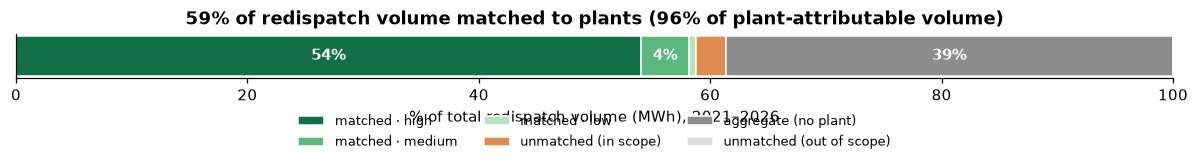

In [3]:
fig, ax = plt.subplots(figsize=(11, 2.4))
left = 0.0
for c in CATS:
    w = 100 * total[c] / tot
    ax.barh(0, w, left=left, color=COLORS[c], edgecolor="white", label=c)
    if w > 3.5:
        ax.text(left + w/2, 0, f"{w:.0f}%", ha="center", va="center",
                color="white" if c != "unmatched (out of scope)" else "#555", fontweight="bold")
    left += w
ax.set_xlim(0, 100); ax.set_yticks([])
ax.set_xlabel("% of total redispatch volume (MWh), 2021–2026")
ax.set_title(f"{matched_pct:.0f}% of redispatch volume matched to plants "
             f"({100*total[MATCHED].sum()/attributable:.0f}% of plant-attributable volume)",
             fontweight="bold")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.55), frameon=False, fontsize=8.5)
plt.tight_layout(); plt.show()

## 2. Year by year

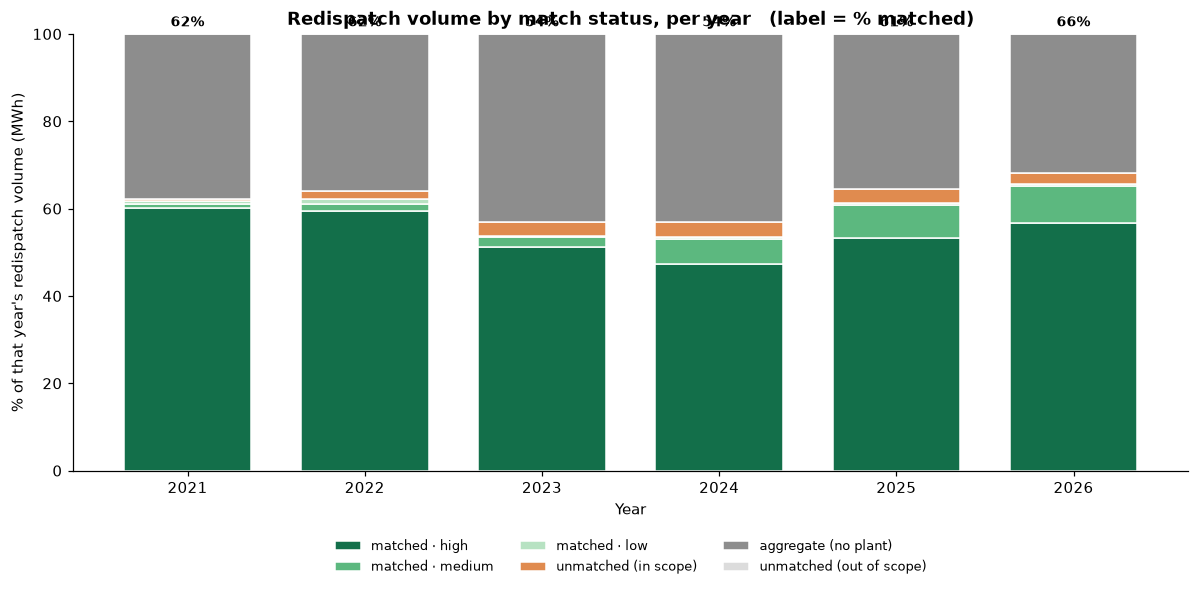

In [4]:
pct = by_year.div(by_year.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(11, 5.5))
bottom = pd.Series(0.0, index=pct.index)
for c in CATS:
    ax.bar(pct.index, pct[c], bottom=bottom, color=COLORS[c], edgecolor="white", width=0.72, label=c)
    bottom += pct[c]
for y in pct.index:
    ax.text(y, 101, f"{pct.loc[y, MATCHED].sum():.0f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylim(0, 100); ax.set_xlabel("Year")
ax.set_ylabel("% of that year's redispatch volume (MWh)")
ax.set_title("Redispatch volume by match status, per year   (label = % matched)", fontweight="bold")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.13), frameon=False, fontsize=8.5)
plt.tight_layout(); plt.show()

Matched share is now a flat ~54–66% across all years — the retired/renamed plants
(nuclear phase-out, old coal) are recovered, so early years no longer lag. The grey
`aggregate` band (~39%) is stable and is the structural ceiling: that volume (countertrade,
control-reserve nodes, regional buckets, foreign plants) has no single plant to match by
construction. Excluding it, **~96% of plant-attributable volume is matched.**

## 3. By confidence

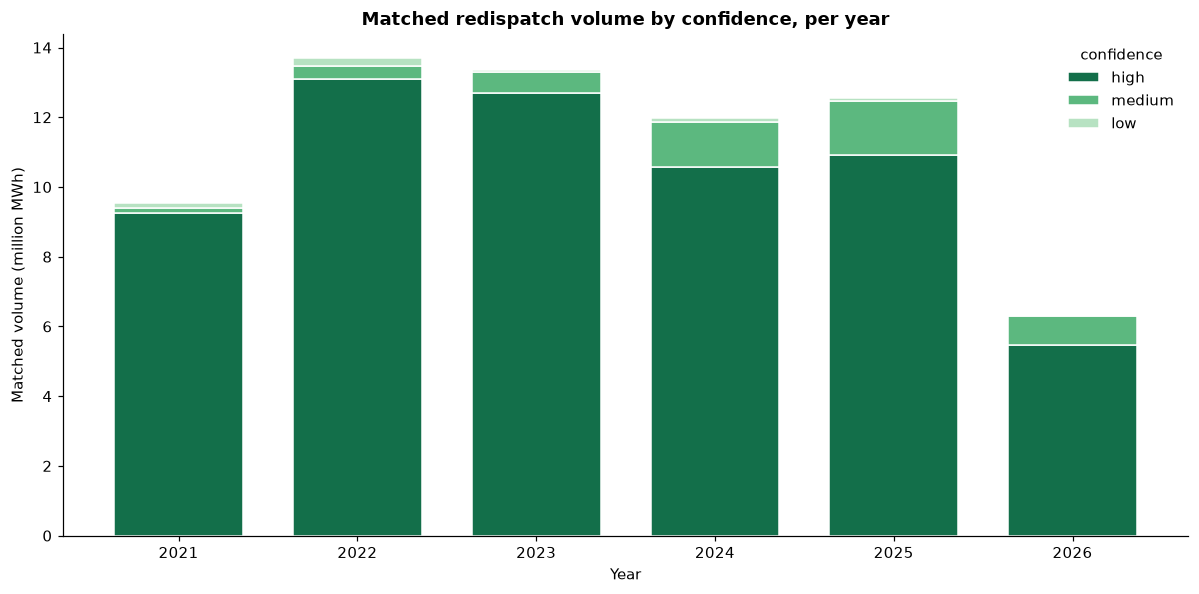

Matched volume by confidence (total 2021-2026):
  matched · high   :  62.0M MWh  (92% of matched)
  matched · medium :   4.8M MWh  (7% of matched)
  matched · low    :   0.6M MWh  (1% of matched)


In [5]:
conf = by_year[MATCHED].rename(columns={"matched · high": "high", "matched · medium": "medium",
                                        "matched · low": "low"}) / 1e6
cc = {"high": "#136f4a", "medium": "#5cb87f", "low": "#b7e2c2"}
fig, ax = plt.subplots(figsize=(11, 5.5))
bottom = pd.Series(0.0, index=conf.index)
for c in ["high", "medium", "low"]:
    ax.bar(conf.index, conf[c], bottom=bottom, color=cc[c], edgecolor="white", width=0.72, label=c)
    bottom += conf[c]
ax.set_xlabel("Year"); ax.set_ylabel("Matched volume (million MWh)")
ax.set_title("Matched redispatch volume by confidence, per year", fontweight="bold")
ax.legend(title="confidence", frameon=False)
plt.tight_layout(); plt.show()

print("Matched volume by confidence (total 2021-2026):")
for c in MATCHED:
    print(f"  {c:17s}: {total[c]/1e6:5.1f}M MWh  ({100*total[c]/total[MATCHED].sum():.0f}% of matched)")

## 4. What makes up the unmatched volume

Of the ~41% unmatched, almost all is **structurally plant-less by design** — chiefly
countertrade (`Börse`) and the offshore-wind substation nodes (`OWP UW …`). Only a small
tail is genuinely unresolved individual plants.

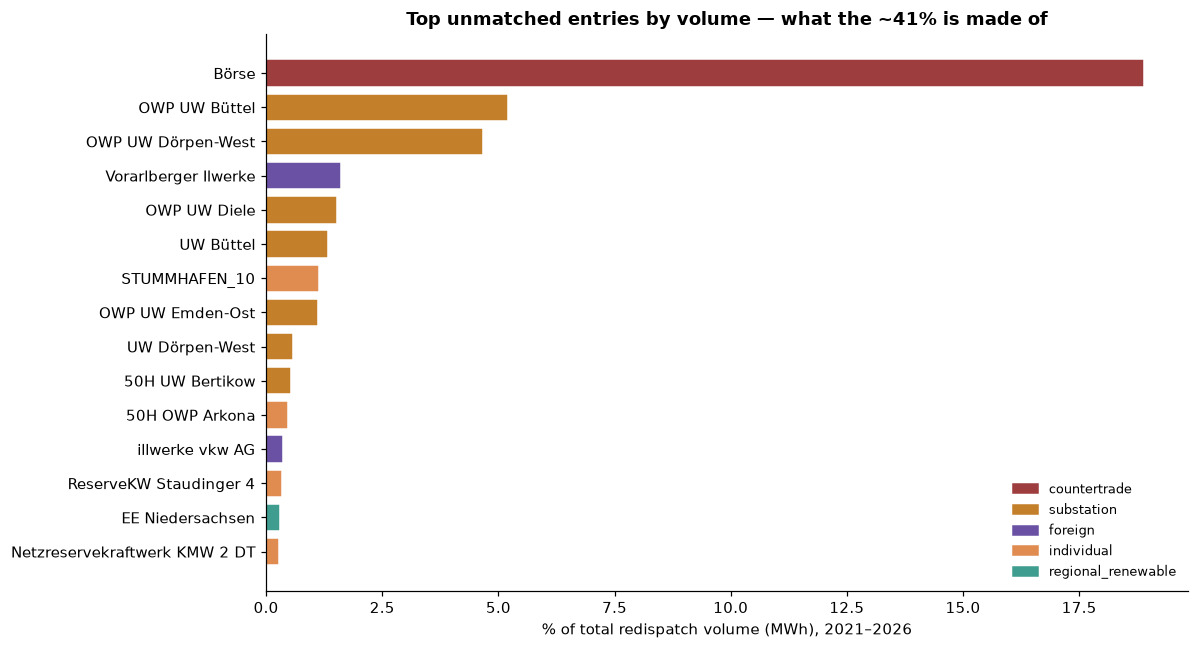

Unmatched volume by category (% of total redispatch volume):
   18.9%  countertrade
   15.8%  substation
    2.6%  individual
    2.0%  foreign
    1.5%  control_reserve
    0.5%  regional_renewable
    0.0%  emergency
    0.0%  cluster


In [6]:
import matplotlib.patches as mpatches

et_of = lambda n: info.get(str(n).strip(), (None, None, "out of scope"))[2]
un = r[~r["category"].str.startswith("matched")].copy()
un["cat"] = un["BETROFFENE_ANLAGE"].map(et_of)

top = (un.groupby(["BETROFFENE_ANLAGE", "cat"])["mwh"].sum()
         .sort_values(ascending=False).head(15).reset_index())

CAT_COL = {"countertrade": "#9e3d3d", "substation": "#c47f2a", "foreign": "#6a51a3",
           "control_reserve": "#8d8d8d", "regional_renewable": "#3f9d8f",
           "individual": "#e08b4f", "emergency": "#c9c9c9"}

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(range(len(top)), 100 * top["mwh"] / tot,
        color=[CAT_COL.get(c, "#999") for c in top["cat"]], edgecolor="white")
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top["BETROFFENE_ANLAGE"].str.slice(0, 42))
ax.invert_yaxis()
ax.set_xlabel("% of total redispatch volume (MWh), 2021–2026")
ax.set_title("Top unmatched entries by volume — what the ~41% is made of", fontweight="bold")
ax.legend(handles=[mpatches.Patch(color=CAT_COL[c], label=c) for c in top["cat"].unique() if c in CAT_COL],
          frameon=False, fontsize=8.5, loc="lower right")
plt.tight_layout(); plt.show()

print("Unmatched volume by category (% of total redispatch volume):")
for k, v in un.groupby("cat")["mwh"].sum().sort_values(ascending=False).items():
    print(f"  {100*v/tot:5.1f}%  {k}")

`Börse` alone is **18.9%** (EPEX countertrade — the exchange, no plant) and the offshore
substations `OWP UW …` add **~16%** (each aggregates several offshore farms feeding one
transformer). Together that's ~35% of *all* redispatch volume with no single plant to point
at, by construction. The genuinely matchable-but-unresolved remainder (individual entries such
as `STUMMHAFEN_10`, `ReserveKW Staudinger 4`) is only **~2.6%** — the offshore substations are
the one place further work (mapping a `UW` node to the farms behind it) could still add coverage.